In [3]:

import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import rdf

DATA = "../prod_traj/prod.data"    
DUMP = "../prod_traj/density.atom"   

u = mda.Universe(DATA, DUMP, topology_format="DATA",
                 format="LAMMPSDUMP")


benzenes = u.select_atoms("type 0 1 2 3 4 5 6 7 8 9 10 11 12")
methanols = u.select_atoms("type 13 14 15 16 17 18")

print(benzenes.n_atoms)
print(methanols.n_atoms)

12
114


/Users/bb24144/miniforge3/envs/Fresh/lib/python3.12/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


In [ ]:
# ----- RDFs ------
class BeadGroup(object):
    def __init__(self, groups):
        self._groups = groups

    def __len__(self):
        return len(self._groups)

    @property
    def positions(self):
        return np.array([g.center_of_mass(unwrap = True) for g in self._groups], dtype=np.float32)

    @property
    def universe(self):
        return self._groups[0].universe

def COM_RDF(u):
    com_groups = u.fragments  # if you have bond information
    c = BeadGroup(com_groups)
    irdf_res = rdf.InterRDF(c,c,range =(0,10), exclusion_block=(1,1), verbose = True)
    irdf_res.run()
    return irdf_res

In [14]:
methanol_rdf = COM_RDF(methanols)

O = u.select_atoms('type 14')
oo = rdf.InterRDF(O, O, range=(0,10), exclude_same='residue')
oo.run(verbose=False)

  0%|          | 0/2001 [00:00<?, ?it/s]

/Users/bb24144/miniforge3/envs/Fresh/lib/python3.12/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


(2.0, 8.0)

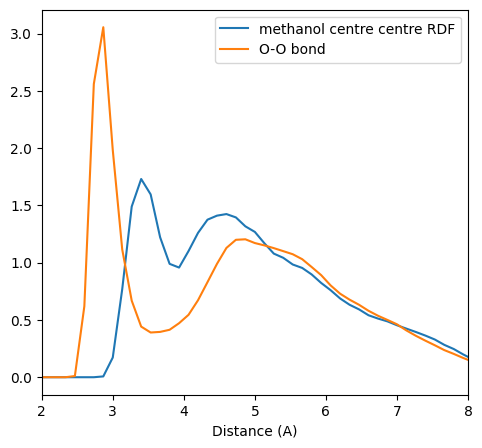

In [16]:
fig, ax = plt.subplots()
fig.set_size_inches(5.5,5)
ax.plot(methanol_rdf.results.bins,methanol_rdf.results.rdf, label = 'methanol centre centre RDF')
ax.plot(oo.results.bins, oo.results.rdf, label = 'O-O bond')


ax.set_xlabel('Distance (A)')
ax.legend()
ax.set_xlim(2,8)

In [20]:
import MDAnalysis.transformations as trans

uw = u.copy()

ag = uw.atoms
transform = trans.wrap(ag)
uw.trajectory.add_transformations(transform)

benzenes_uw = u.select_atoms("type 0 1 2 3 4 5 6 7 8 9 10 11 12")
methanols_uw = u.select_atoms("type 13 14 15 16 17 18")

benz_com, meoh_com = [], []
for ts in u.trajectory:
    benz_com.append(benzenes_uw.center_of_mass())
    meoh_com.append(methanols_uw.center_of_mass(compound='residues'))
benz_com = np.array(benz_com)             # (nframes, 3)
meoh_com = np.array(meoh_com)             # (nframes, 19, 3)
print('COM trajectories:', benz_com.shape, meoh_com.shape)

/Users/bb24144/miniforge3/envs/Fresh/lib/python3.12/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


COM trajectories: (2001, 3) (2001, 19, 3)


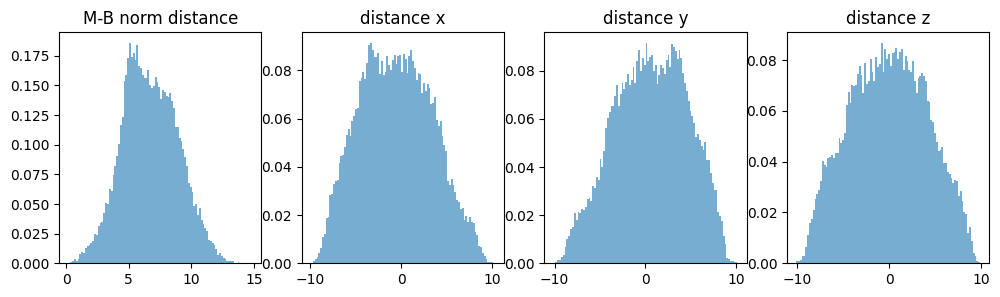

In [37]:
COM_dists_3D = (meoh_com - benz_com[:,np.newaxis]).reshape(-1,3)
COM_dists = np.linalg.norm(COM_dists_3D,axis=1)

fig,ax = plt.subplots(1,4,figsize = (12,3))

ax[0].hist(COM_dists,density = True, bins =100, alpha = 0.6)

for i in range(3):
    ax[i+1].hist(COM_dists_3D[:,i],density = True, bins =100, alpha = 0.6)


ax[0].set_title('M-B norm distance')
ax[1].set_title('distance x')
ax[2].set_title('distance y')
ax[3].set_title('distance z')

plt.show()